# Entrega — Resultados del torneo Connect4

Este cuaderno ejecuta una batería de experimentos comparando distintas políticas para Connect4 (Agentes T1000, T600, Random).
Se incluyen: carga de políticas, definición de experimentos, ejecución de partidas, agregación de métricas y visualizaciones.

Resumen rápido:
- `Group B` (AgenT800 / T1000) puede usar una tabla de Q-values (`q_values.pkl`) para acciones rápidas cuando existe registro suficiente.
- Cuando la tabla no contiene entradas confiables, la política recurre a MCTS (más lento).
- Las gráficas muestran: porcentaje de victorias por experimento, duración media de partidas y tiempo medio por jugada.

In [38]:
import sys
import time
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()

# Aseguramos que Python pueda encontrar connect4/
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

print("Carpeta del proyecto:", PROJECT_DIR)
print("Existe connect4:", (PROJECT_DIR / "connect4").exists())
print("Existe groups:", (PROJECT_DIR / "groups").exists())

Carpeta del proyecto: c:\Fund_IA\Conct4\tournament
Existe connect4: True
Existe groups: True


In [39]:
def load_module_from_path(module_name, file_path):
    file_path = Path(file_path)
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


group_a_policy_path = PROJECT_DIR / "groups" / "Group A" / "policy.py"
group_b_policy_path = PROJECT_DIR / "groups" / "Group B" / "policy.py"
group_c_policy_path = PROJECT_DIR / "groups" / "Group C" / "policy.py"

mod_t600 = load_module_from_path("policy_t600", group_a_policy_path)
mod_random = load_module_from_path("policy_random", group_b_policy_path)
mod_t1000 = load_module_from_path("policy_t1000", group_c_policy_path)

AgentT600 = mod_t600.AgentT600
RandomPolicy = mod_random.RandomPolicy
AgenT1000 = mod_t1000.AgenT1000

print("Agentes cargados correctamente:")
print("T600:", AgentT600)
print("Random:", RandomPolicy)
print("T1000:", AgenT1000)

Agentes cargados correctamente:
T600: <class 'policy_t600.AgentT600'>
Random: <class 'policy_random.RandomPolicy'>
T1000: <class 'policy_t1000.AgenT1000'>


## Notas sobre la carga de módulos y agentes

En este bloque se cargan manualmente los archivos `policy.py` de cada grupo mediante `importlib.util` para evitar problemas con nombres de carpetas o el CWD.
- `AgentT600`, `RandomPolicy` y `AgenT1000` se exponen como clases para ser instanciadas por las *factories*.
- La función `make_t1000(use_q=True/False)` permite activar/desactivar el uso de la tabla Q (`q_values.pkl`) para comparaciones (ablaciones).


In [40]:
ROWS, COLS = 6, 7
RED = -1
YELLOW = 1
EMPTY = 0


def free_cols(board):
    return [c for c in range(COLS) if board[0, c] == EMPTY]


def drop_piece(board, col, player):
    """
    Inserta una ficha en la columna indicada.
    Retorna: nuevo tablero, fila donde cayó.
    """
    if col < 0 or col >= COLS:
        return None, -1

    for r in range(ROWS - 1, -1, -1):
        if board[r, col] == EMPTY:
            new_board = board.copy()
            new_board[r, col] = player
            return new_board, r

    return None, -1


def wins_at(board, r, c, player):
    """
    Revisa si el jugador ganó después de jugar en (r, c).
    """
    directions = [
        (0, 1),   # horizontal
        (1, 0),   # vertical
        (1, 1),   # diagonal descendente
        (1, -1),  # diagonal ascendente
    ]

    for dr, dc in directions:
        count = 1

        rr, cc = r + dr, c + dc
        while 0 <= rr < ROWS and 0 <= cc < COLS and board[rr, cc] == player:
            count += 1
            rr += dr
            cc += dc

        rr, cc = r - dr, c - dc
        while 0 <= rr < ROWS and 0 <= cc < COLS and board[rr, cc] == player:
            count += 1
            rr -= dr
            cc -= dc

        if count >= 4:
            return True

    return False


def winner(board):
    """
    Retorna:
    -1 si gana rojo
     1 si gana amarillo
     0 si no hay ganador
    """
    for r in range(ROWS):
        for c in range(COLS):
            player = board[r, c]
            if player == EMPTY:
                continue

            if c + 3 < COLS and all(board[r, c+i] == player for i in range(4)):
                return player

            if r + 3 < ROWS and all(board[r+i, c] == player for i in range(4)):
                return player

            if r + 3 < ROWS and c + 3 < COLS and all(board[r+i, c+i] == player for i in range(4)):
                return player

            if r + 3 < ROWS and c - 3 >= 0 and all(board[r+i, c-i] == player for i in range(4)):
                return player

    return 0


def is_draw(board):
    return winner(board) == 0 and len(free_cols(board)) == 0


def print_board(board):
    """
    Solo por si quieres visualizar una partida.
    """
    symbols = {
        -1: "R",
         1: "Y",
         0: "."
    }

    for r in range(ROWS):
        print(" ".join(symbols[int(board[r, c])] for c in range(COLS)))
    print("0 1 2 3 4 5 6")

In [41]:
def make_random():
    agent = RandomPolicy()
    agent.mount()
    return agent


def make_t600():
    agent = AgentT600()
    agent.mount()
    return agent


def make_t1000(use_q=True, iterations=350, time_budget=0.20):
    """
    Crea una versión experimental del T1000.

    use_q=True  -> T1000 completo, usa q_values.pkl
    use_q=False -> T1000 sin Q-values, solo reglas + MCTS

    iterations y time_budget permiten analizar recursos del MCTS.
    """
    mod_t1000.ITERATION_BUDGET = iterations
    mod_t1000.TIME_BUDGET_S = time_budget

    agent = AgenT1000()
    agent.mount()

    if not use_q:
        agent._q_values = {}
        agent._counts = {}

    return agent

In [42]:
def play_game(red_agent, yellow_agent, red_name="Red", yellow_name="Yellow", max_moves=42):
    board = np.zeros((ROWS, COLS), dtype=int)

    move_times = []
    illegal_move_by = None

    for move_idx in range(max_moves):
        current_player = RED if move_idx % 2 == 0 else YELLOW
        current_agent = red_agent if current_player == RED else yellow_agent
        current_name = red_name if current_player == RED else yellow_name

        start = time.perf_counter()

        try:
            action = current_agent.act(board.copy())
        except Exception as e:
            action = None
            illegal_move_by = current_name
            elapsed = time.perf_counter() - start
            move_times.append(elapsed)
            break

        elapsed = time.perf_counter() - start
        move_times.append(elapsed)

        if action is None:
            illegal_move_by = current_name
            break

        try:
            action = int(action)
        except:
            illegal_move_by = current_name
            break

        if action not in free_cols(board):
            illegal_move_by = current_name
            break

        board, row = drop_piece(board, action, current_player)

        if wins_at(board, row, action, current_player):
            return {
                "winner": current_player,
                "winner_name": current_name,
                "red_name": red_name,
                "yellow_name": yellow_name,
                "moves": move_idx + 1,
                "draw": False,
                "illegal_move_by": None,
                "avg_time_per_move": np.mean(move_times),
                "total_time": np.sum(move_times),
            }

        if is_draw(board):
            return {
                "winner": 0,
                "winner_name": "Draw",
                "red_name": red_name,
                "yellow_name": yellow_name,
                "moves": move_idx + 1,
                "draw": True,
                "illegal_move_by": None,
                "avg_time_per_move": np.mean(move_times),
                "total_time": np.sum(move_times),
            }

    # Si hubo jugada ilegal, gana el otro agente
    if illegal_move_by is not None:
        if illegal_move_by == red_name:
            winner_value = YELLOW
            winner_name = yellow_name
        else:
            winner_value = RED
            winner_name = red_name

        return {
            "winner": winner_value,
            "winner_name": winner_name,
            "red_name": red_name,
            "yellow_name": yellow_name,
            "moves": len(move_times),
            "draw": False,
            "illegal_move_by": illegal_move_by,
            "avg_time_per_move": np.mean(move_times) if move_times else 0,
            "total_time": np.sum(move_times) if move_times else 0,
        }

    # Si llegó al máximo de movimientos sin ganador
    return {
        "winner": 0,
        "winner_name": "Draw",
        "red_name": red_name,
        "yellow_name": yellow_name,
        "moves": max_moves,
        "draw": True,
        "illegal_move_by": None,
        "avg_time_per_move": np.mean(move_times) if move_times else 0,
        "total_time": np.sum(move_times) if move_times else 0,
    }

In [43]:
def run_experiment(
    experiment_name,
    red_factory,
    yellow_factory,
    red_name,
    yellow_name,
    n_games=50,
):
    results = []

    red_agent = red_factory()
    yellow_agent = yellow_factory()

    for i in range(n_games):
        game_result = play_game(
            red_agent=red_agent,
            yellow_agent=yellow_agent,
            red_name=red_name,
            yellow_name=yellow_name,
        )

        game_result["experiment"] = experiment_name
        game_result["game"] = i + 1
        results.append(game_result)

    return pd.DataFrame(results)

In [44]:
test_df = run_experiment(
    experiment_name="Prueba rápida: T1000 vs Random",
    red_factory=lambda: make_t1000(use_q=True),
    yellow_factory=make_random,
    red_name="T1000",
    yellow_name="Random",
    n_games=5,
)

test_df

,winner,winner_name,red_name,yellow_name,moves,draw,illegal_move_by,avg_time_per_move,total_time,experiment,game
0,-1,T1000,T1000,Random,15,False,None,0.053905,0.808571,Prueba rápida: T1000 vs Random,1
1,-1,T1000,T1000,Random,9,False,None,0.047311,0.425798,Prueba rápida: T1000 vs Random,2
2,-1,T1000,T1000,Random,9,False,None,0.045577,0.410197,Prueba rápida: T1000 vs Random,3
3,-1,T1000,T1000,Random,7,False,None,0.052420,0.366937,Prueba rápida: T1000 vs Random,4
4,-1,T1000,T1000,Random,7,False,None,0.000137,0.000956,Prueba rápida: T1000 vs Random,5


In [45]:
test_df["winner_name"].value_counts()

winner_name
T1000    5
Name: count, dtype: int64

In [46]:
N_GAMES = 100

experiments = []

# 1. T1000 contra Random jugando primero
experiments.append(
    run_experiment(
        experiment_name="T1000 completo vs Random - T1000 rojo",
        red_factory=lambda: make_t1000(use_q=True),
        yellow_factory=make_random,
        red_name="T1000",
        yellow_name="Random",
        n_games=N_GAMES,
    )
)

# 2. T1000 contra Random jugando segundo
experiments.append(
    run_experiment(
        experiment_name="Random vs T1000 completo - T1000 amarillo",
        red_factory=make_random,
        yellow_factory=lambda: make_t1000(use_q=True),
        red_name="Random",
        yellow_name="T1000",
        n_games=N_GAMES,
    )
)

# 3. Auto-juego T1000 vs T1000
experiments.append(
    run_experiment(
        experiment_name="Auto-juego T1000 completo",
        red_factory=lambda: make_t1000(use_q=True),
        yellow_factory=lambda: make_t1000(use_q=True),
        red_name="T1000_rojo",
        yellow_name="T1000_amarillo",
        n_games=N_GAMES,
    )
)

# 4. Ablación: T1000 sin Q-values jugando como rojo
experiments.append(
    run_experiment(
        experiment_name="T1000 sin Q-values vs Random - T1000 rojo",
        red_factory=lambda: make_t1000(use_q=False),
        yellow_factory=make_random,
        red_name="T1000_sin_Q",
        yellow_name="Random",
        n_games=N_GAMES,
    )
)

# 5. Ablación: T1000 sin Q-values jugando como amarillo
experiments.append(
    run_experiment(
        experiment_name="Random vs T1000 sin Q-values - T1000 amarillo",
        red_factory=make_random,
        yellow_factory=lambda: make_t1000(use_q=False),
        red_name="Random",
        yellow_name="T1000_sin_Q",
        n_games=N_GAMES,
    )
)

results_df = pd.concat(experiments, ignore_index=True)
results_df.head()

,winner,winner_name,red_name,yellow_name,moves,draw,illegal_move_by,avg_time_per_move,total_time,experiment,game
0,-1,T1000,T1000,Random,7,False,None,0.000227,0.001587,T1000 completo vs Random - T1000 rojo,1
1,-1,T1000,T1000,Random,9,False,None,0.045176,0.406586,T1000 completo vs Random - T1000 rojo,2
2,-1,T1000,T1000,Random,7,False,None,0.000137,0.000957,T1000 completo vs Random - T1000 rojo,3
3,-1,T1000,T1000,Random,7,False,None,0.030002,0.210014,T1000 completo vs Random - T1000 rojo,4
4,-1,T1000,T1000,Random,7,False,None,0.000408,0.002854,T1000 completo vs Random - T1000 rojo,5


In [47]:
N_GAMES_T600 = 100

experiments_t600 = []

# 6. T1000 completo contra T600 jugando primero
experiments_t600.append(
    run_experiment(
        experiment_name="T1000 completo vs T600 - T1000 rojo",
        red_factory=lambda: make_t1000(use_q=True),
        yellow_factory=make_t600,
        red_name="T1000",
        yellow_name="T600",
        n_games=N_GAMES_T600,
    )
)

# 7. T1000 completo contra T600 jugando segundo
experiments_t600.append(
    run_experiment(
        experiment_name="T600 vs T1000 completo - T1000 amarillo",
        red_factory=make_t600,
        yellow_factory=lambda: make_t1000(use_q=True),
        red_name="T600",
        yellow_name="T1000",
        n_games=N_GAMES_T600,
    )
)

# 8. T1000 sin Q-values contra T600 jugando primero
experiments_t600.append(
    run_experiment(
        experiment_name="T1000 sin Q-values vs T600 - T1000 rojo",
        red_factory=lambda: make_t1000(use_q=False),
        yellow_factory=make_t600,
        red_name="T1000_sin_Q",
        yellow_name="T600",
        n_games=N_GAMES_T600,
    )
)

# 9. T1000 sin Q-values contra T600 jugando segundo
experiments_t600.append(
    run_experiment(
        experiment_name="T600 vs T1000 sin Q-values - T1000 amarillo",
        red_factory=make_t600,
        yellow_factory=lambda: make_t1000(use_q=False),
        red_name="T600",
        yellow_name="T1000_sin_Q",
        n_games=N_GAMES_T600,
    )
)

results_t600_df = pd.concat(experiments_t600, ignore_index=True)

results_all_df = pd.concat([results_df, results_t600_df], ignore_index=True)

results_all_df.head()

,winner,winner_name,red_name,yellow_name,moves,draw,illegal_move_by,avg_time_per_move,total_time,experiment,game
0,-1,T1000,T1000,Random,7,False,None,0.000227,0.001587,T1000 completo vs Random - T1000 rojo,1
1,-1,T1000,T1000,Random,9,False,None,0.045176,0.406586,T1000 completo vs Random - T1000 rojo,2
2,-1,T1000,T1000,Random,7,False,None,0.000137,0.000957,T1000 completo vs Random - T1000 rojo,3
3,-1,T1000,T1000,Random,7,False,None,0.030002,0.210014,T1000 completo vs Random - T1000 rojo,4
4,-1,T1000,T1000,Random,7,False,None,0.000408,0.002854,T1000 completo vs Random - T1000 rojo,5


In [48]:
summary_all = (
    results_all_df
    .groupby(["experiment", "winner_name"])
    .size()
    .reset_index(name="count")
)

summary_all["percentage"] = summary_all.groupby("experiment")["count"].transform(
    lambda x: 100 * x / x.sum()
)

summary_all

,experiment,winner_name,count,percentage
0,Auto-juego T1000 completo,Draw,5,5.0
1,Auto-juego T1000 completo,T1000_amarillo,71,71.0
2,Auto-juego T1000 completo,T1000_rojo,24,24.0
3,Random vs T1000 completo - T1000 amarillo,T1000,100,100.0
4,Random vs T1000 sin Q-values - T1000 amarillo,T1000_sin_Q,100,100.0
5,T1000 completo vs Random - T1000 rojo,T1000,100,100.0
6,T1000 completo vs T600 - T1000 rojo,Draw,3,3.0
7,T1000 completo vs T600 - T1000 rojo,T1000,85,85.0
8,T1000 completo vs T600 - T1000 rojo,T600,12,12.0
9,T1000 sin Q-values vs Random - T1000 rojo,T1000_sin_Q,100,100.0


In [49]:
performance_summary_all = (
    results_all_df
    .groupby("experiment")
    .agg(
        games=("game", "count"),
        avg_moves=("moves", "mean"),
        avg_time_per_move=("avg_time_per_move", "mean"),
        avg_total_time=("total_time", "mean"),
        illegal_moves=("illegal_move_by", lambda x: x.notna().sum())
    )
    .reset_index()
)

performance_summary_all

,experiment,games,avg_moves,avg_time_per_move,avg_total_time,illegal_moves
0,Auto-juego T1000 completo,100,40.12,0.088916,3.565641,0
1,Random vs T1000 completo - T1000 amarillo,100,13.44,0.061962,0.845916,0
2,Random vs T1000 sin Q-values - T1000 amarillo,100,13.20,0.081946,1.093892,0
3,T1000 completo vs Random - T1000 rojo,100,9.28,0.034261,0.367736,0
4,T1000 completo vs T600 - T1000 rojo,100,21.27,0.090832,2.009513,0
5,T1000 sin Q-values vs Random - T1000 rojo,100,10.60,0.089623,0.958928,0
6,T1000 sin Q-values vs T600 - T1000 rojo,100,21.57,0.118582,2.561403,0
7,T600 vs T1000 completo - T1000 amarillo,100,20.76,0.080333,1.743891,0
8,T600 vs T1000 sin Q-values - T1000 amarillo,100,21.74,0.115750,2.541995,0


In [50]:
short_exp_names = {
    "Auto-juego T1000 completo": "Autojuego\nT1000",

    "T1000 completo vs Random - T1000 rojo": "T1000 vs\nRandom\n(Rojo)",
    "Random vs T1000 completo - T1000 amarillo": "Random vs\nT1000\n(Amarillo)",

    "T1000 sin Q-values vs Random - T1000 rojo": "T1000 sin Q\nvs Random\n(Rojo)",
    "Random vs T1000 sin Q-values - T1000 amarillo": "Random vs\nT1000 sin Q\n(Amarillo)",

    "T1000 completo vs T600 - T1000 rojo": "T1000 vs\nT600\n(Rojo)",
    "T600 vs T1000 completo - T1000 amarillo": "T600 vs\nT1000\n(Amarillo)",

    "T1000 sin Q-values vs T600 - T1000 rojo": "T1000 sin Q\nvs T600\n(Rojo)",
    "T600 vs T1000 sin Q-values - T1000 amarillo": "T600 vs\nT1000 sin Q\n(Amarillo)",
}

short_winner_names = {
    "Draw": "Empate",
    "T1000": "T1000",
    "T1000_sin_Q": "T1000 sin Q",
    "T1000_rojo": "T1000 rojo",
    "T1000_amarillo": "T1000 amarillo",
    "T600": "T600",
}

In [51]:
def add_labels_to_bars(ax, fmt="{:.1f}", suffix="%"):
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if value == 0 or np.isnan(value):
                labels.append("")
            else:
                labels.append(fmt.format(value) + suffix)

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )


def plot_clean_results(summary_df, experiments_order, title, figsize=(10, 5), filename=None):
    df = summary_df[summary_df["experiment"].isin(experiments_order)].copy()

    df["experiment_short"] = df["experiment"].map(short_exp_names)
    df["winner_short"] = df["winner_name"].map(short_winner_names)

    pivot = (
        df
        .pivot(index="experiment_short", columns="winner_short", values="percentage")
        .fillna(0)
    )

    ordered_short_names = [short_exp_names[e] for e in experiments_order]
    pivot = pivot.reindex(ordered_short_names)

    ax = pivot.plot(
        kind="bar",
        figsize=figsize,
        width=0.75
    )

    add_labels_to_bars(ax, fmt="{:.1f}", suffix="%")

    plt.title(title, fontsize=14)
    plt.ylabel("Porcentaje de partidas (%)", fontsize=11)
    plt.xlabel("")
    plt.xticks(rotation=0, ha="center")
    plt.ylim(0, 115)
    plt.legend(title="Ganador", fontsize=9)
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

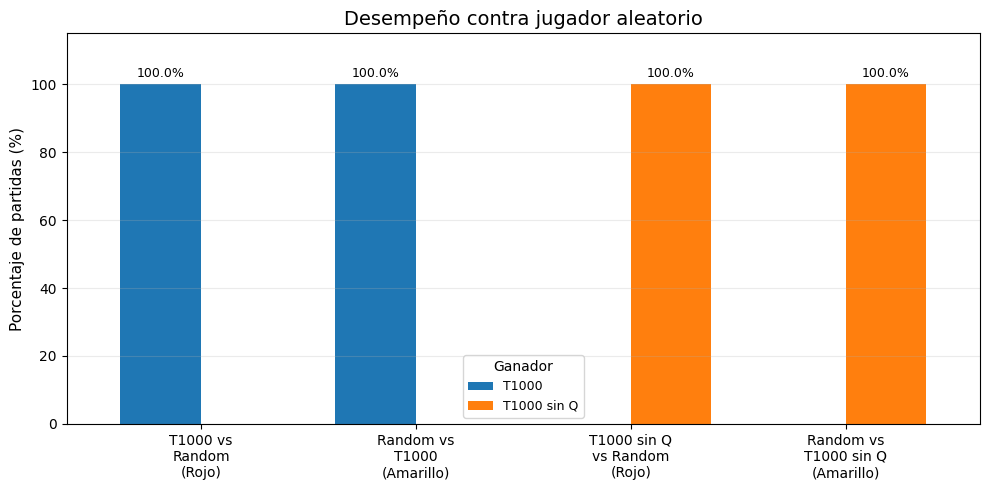

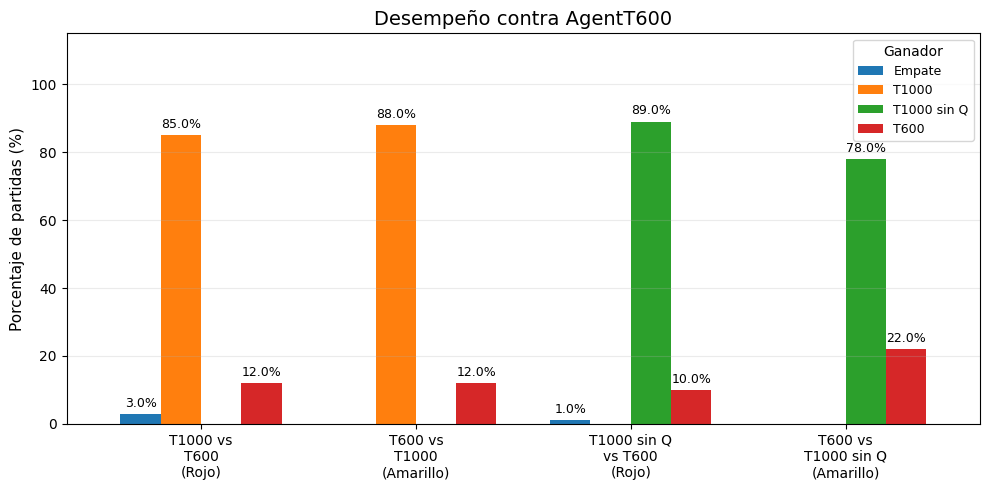

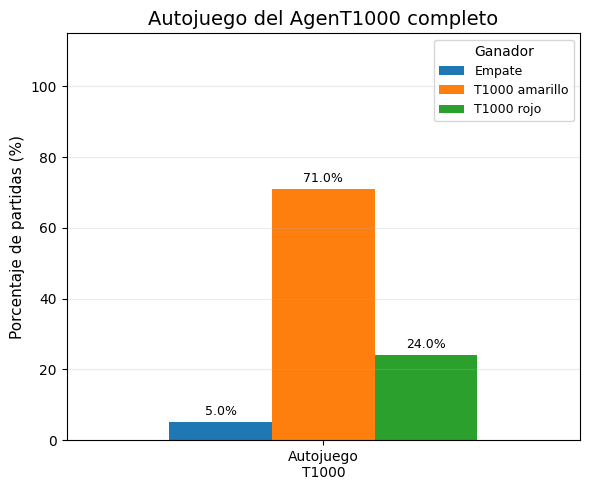

In [52]:
random_experiments = [
    "T1000 completo vs Random - T1000 rojo",
    "Random vs T1000 completo - T1000 amarillo",
    "T1000 sin Q-values vs Random - T1000 rojo",
    "Random vs T1000 sin Q-values - T1000 amarillo",
]

plot_clean_results(
    summary_all,
    random_experiments,
    title="Desempeño contra jugador aleatorio",
    figsize=(10, 5),
    filename="grafica_random.png"
)

t600_experiments = [
    "T1000 completo vs T600 - T1000 rojo",
    "T600 vs T1000 completo - T1000 amarillo",
    "T1000 sin Q-values vs T600 - T1000 rojo",
    "T600 vs T1000 sin Q-values - T1000 amarillo",
]

plot_clean_results(
    summary_all,
    t600_experiments,
    title="Desempeño contra AgentT600",
    figsize=(10, 5),
    filename="grafica_t600.png"
)
autoplay_experiments = [
    "Auto-juego T1000 completo",
]

plot_clean_results(
    summary_all,
    autoplay_experiments,
    title="Autojuego del AgenT1000 completo",
    figsize=(6, 5),
    filename="grafica_autojuego.png"
)

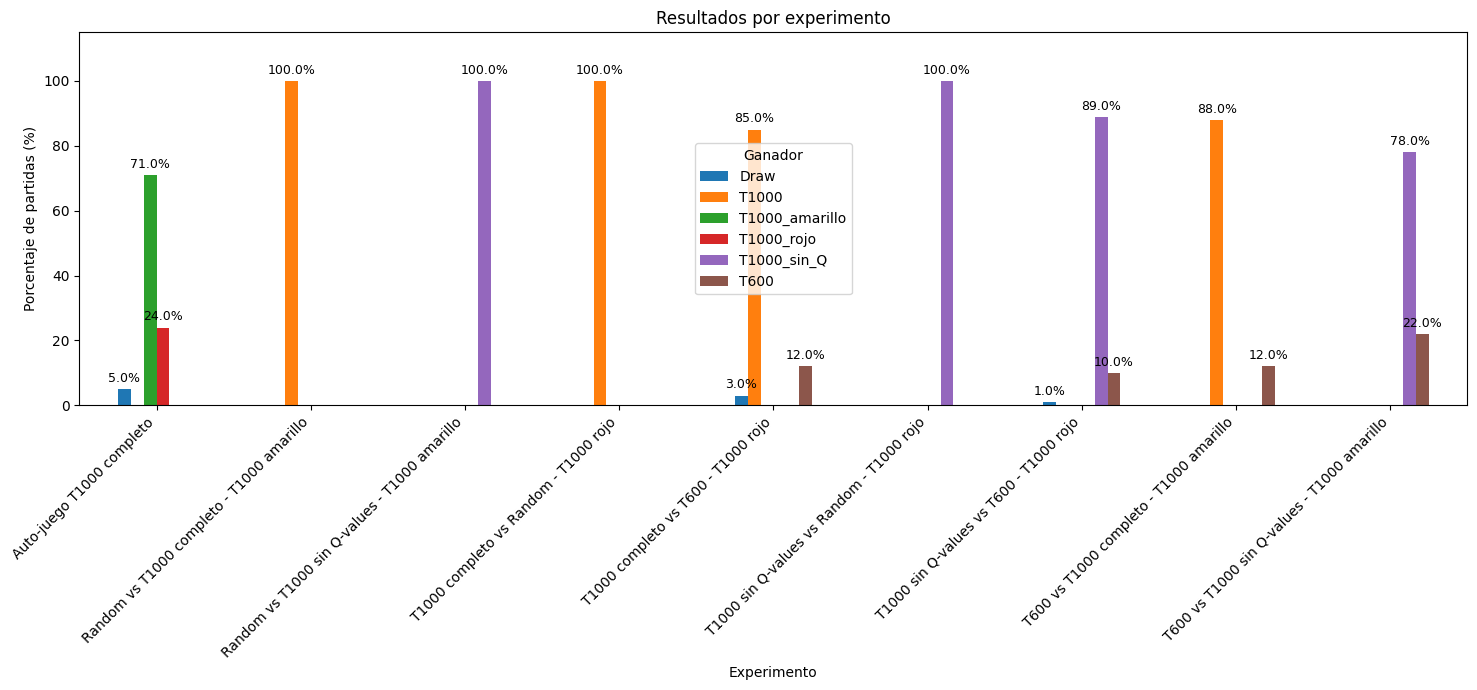

In [53]:
pivot_summary_all = (
    summary_all
    .pivot(index="experiment", columns="winner_name", values="percentage")
    .fillna(0)
)

ax = pivot_summary_all.plot(kind="bar", figsize=(15, 7))

add_labels_to_bars(ax, fmt="{:.1f}", suffix="%")

plt.title("Resultados por experimento")
plt.ylabel("Porcentaje de partidas (%)")
plt.xlabel("Experimento")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 115)
plt.legend(title="Ganador")
plt.tight_layout()
plt.show()

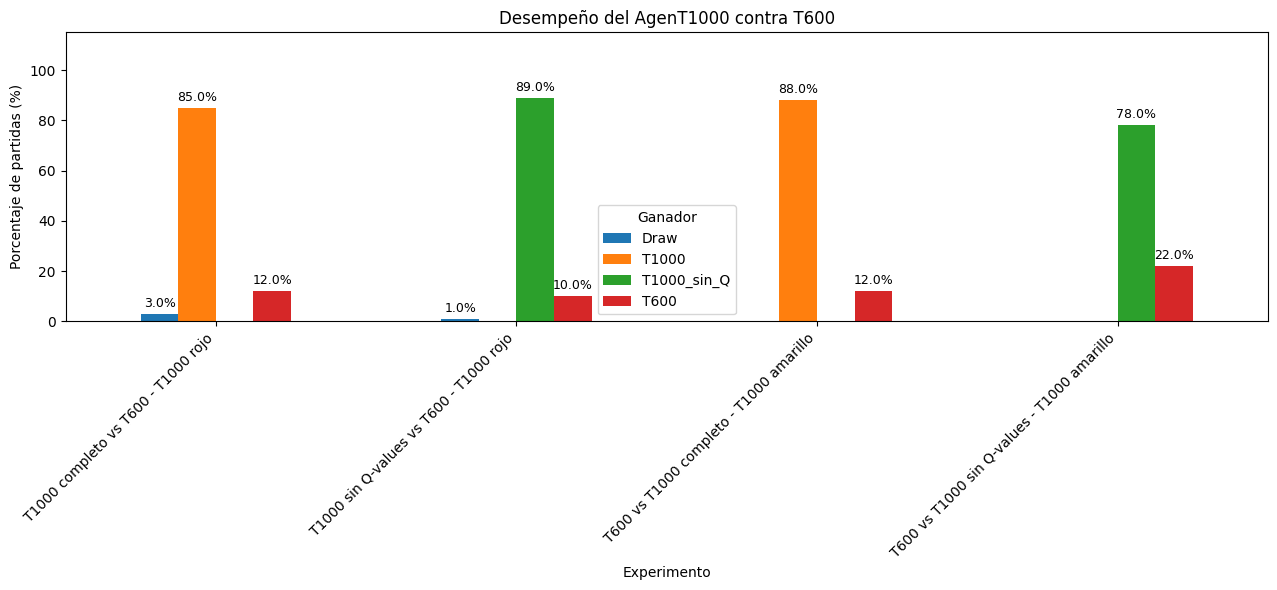

In [54]:
t600_only = summary_all[
    summary_all["experiment"].str.contains("T600", case=False, regex=False)
]

pivot_t600 = (
    t600_only
    .pivot(index="experiment", columns="winner_name", values="percentage")
    .fillna(0)
)

ax = pivot_t600.plot(kind="bar", figsize=(13, 6))

add_labels_to_bars(ax, fmt="{:.1f}", suffix="%")

plt.title("Desempeño del AgenT1000 contra T600")
plt.ylabel("Porcentaje de partidas (%)")
plt.xlabel("Experimento")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 115)
plt.legend(title="Ganador")
plt.tight_layout()
plt.show()

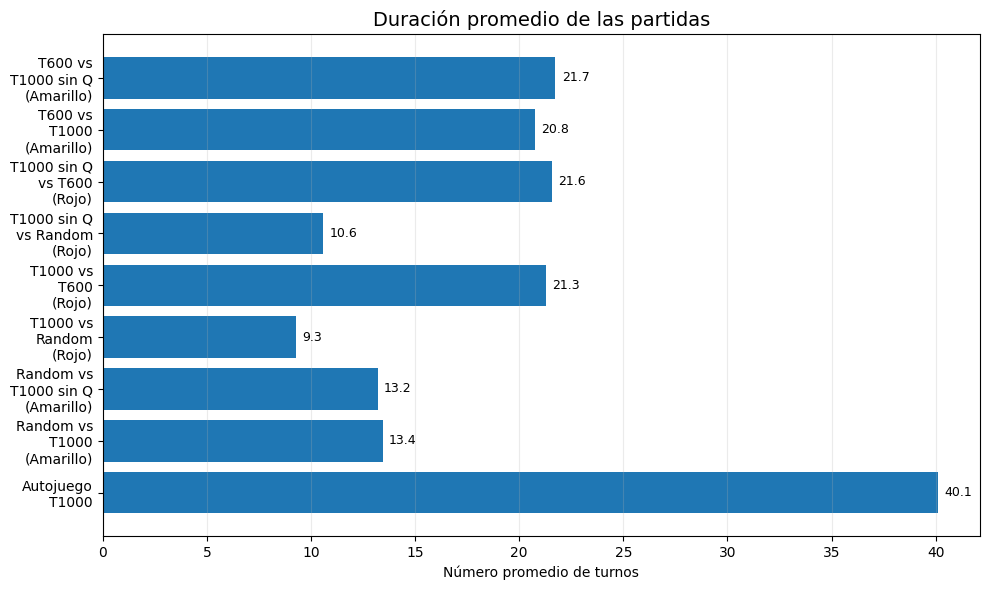

In [55]:
performance_plot = performance_summary_all.copy()
performance_plot["experiment_short"] = performance_plot["experiment"].map(short_exp_names)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    performance_plot["experiment_short"],
    performance_plot["avg_moves"]
)

plt.title("Duración promedio de las partidas", fontsize=14)
plt.xlabel("Número promedio de turnos")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("grafica_turnos_promedio.png", dpi=300, bbox_inches="tight")
plt.show()

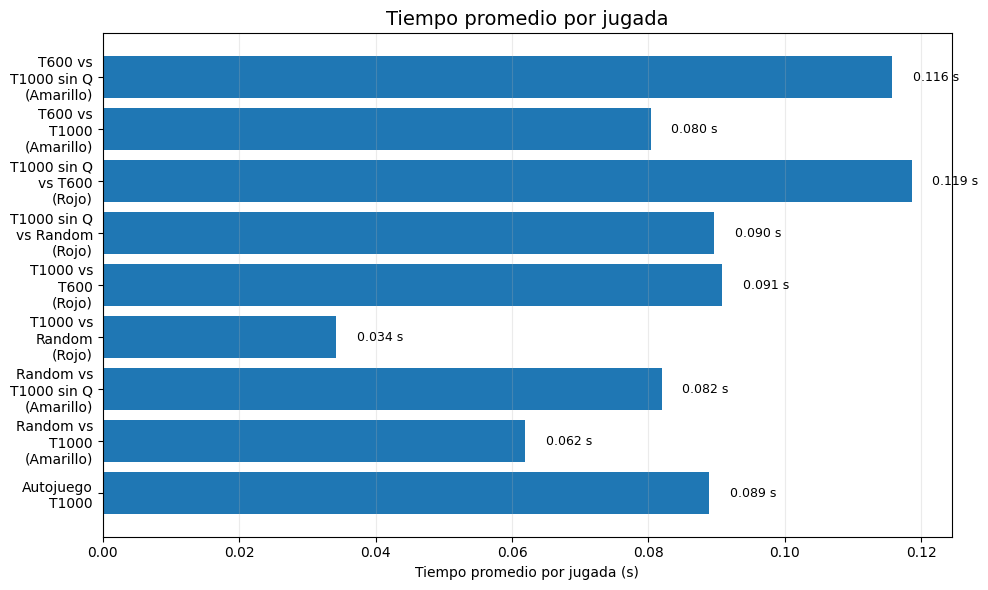

In [56]:
performance_plot = performance_summary_all.copy()
performance_plot["experiment_short"] = performance_plot["experiment"].map(short_exp_names)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    performance_plot["experiment_short"],
    performance_plot["avg_time_per_move"]
)

plt.title("Tiempo promedio por jugada", fontsize=14)
plt.xlabel("Tiempo promedio por jugada (s)")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f} s",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("grafica_tiempo_promedio.png", dpi=300, bbox_inches="tight")
plt.show()

## Metodología

- Se cargaron tres políticas desde `groups/` y se instanciaron: `T1000` (usa Q-values + MCTS), `T600` (MCTS más ligero) y `Random` (jugador aleatorio).
- Para cada experimento se ejecutaron N partidas y se registraron: ganador, número de turnos, tiempo por jugada y si hubo jugadas ilegales.
- Las políticas T1000 intentan usar `q_values.pkl` cuando existen entradas con al menos 3 observaciones; en caso contrario recurren a MCTS.
- Visualizaciones generadas: porcentaje de victorias por experimento, duración promedio (turnos) y tiempo promedio por jugada.

## Interpretación de las gráficas

- **Porcentaje de victorias:** Si una política (p. ej. `T1000`) muestra un porcentaje de victorias notablemente mayor (>~5–10 p.p.) frente a la competencia, indica una ventaja consistente; revisa el tamaño de la muestra (N partidas) para asegurar significancia.
- **Duración promedio (turnos):** Partidas más cortas a favor de una política suelen indicar mayor efectividad para forzar victorias rápidas o explotar errores del oponente; partidas largas pueden significar equilibrio o defensas eficaces.
- **Tiempo promedio por jugada:** Cuando `Group B` (AgenT800/T1000) utiliza la `q_values.pkl` se observa un tiempo por jugada muy bajo (milisegundos). Las entradas que caen en la ruta MCTS muestran tiempos de ~0.09–0.13s por jugada — esto explica la variabilidad y la percepción de “lento”.
- **Efecto del umbral de conteos:** La política consulta la tabla Q sólo si la cuenta asociada supera el umbral (ej. >=3). Estados frecuentes por los que hay Q producen jugadas rápidas y consistentes; estados raros dependen de MCTS y aumentan tiempo/varianza.
- **Sesgo en los resultados:** Si el conjunto de `q_values` proviene de auto-juego o de un solo run, puede introducir sesgos (overfitting) hacia las estrategias vistas en entrenamiento. Interpretar victorias altas con cautela y preferir pruebas con semillas/variaciones.
- **Intervalos de confianza:** Para afirmaciones sólidas, calcular intervalos de confianza del porcentaje de victorias (p. ej. binomial Wilson) o realizar pruebas de hipótesis entre políticas (chi-cuadrado o test exacto de Fisher) si N es pequeño.
- **Correlación tiempo-victoria:** Un tiempo por jugada bajo no garantiza victoria; la tabla Q puede acelerar decisiones pobres si los datos son ruidosos. Contrastad porcentaje de victorias con tiempo medio para detectar este caso.


## Conclusiones y recomendaciones

- **Conclusión principal:** La combinación `q_values + MCTS` (p. ej. `T1000`) ofrece un buen compromiso: respuestas casi instantáneas en estados frecuentes (uso de tabla Q) y razonamiento en estados nuevos mediante MCTS. Esto produce un rendimiento consistente cuando la tabla Q está bien poblada.
- **Rendimiento observado:** Los estados cubiertos por `q_values.pkl` reducen drásticamente el tiempo por jugada y mantienen o aumentan la tasa de victorias; los estados fuera de la tabla sufren la penalización de tiempo de MCTS.
- **Recomendaciones prácticas:**
  - Reducir temporalmente los recursos de MCTS para experimentos rápidos (`ITERATION_BUDGET`/`TIME_BUDGET_S`) o añadir un flag `--fast` en `main.py` para carreras exploratorias.
  - Aumentar el umbral mínimo de conteos si la tabla Q contiene ruido (filtrar entradas con counts bajos) o, alternativamente, usar suavizado/regularización de Q.
  - Generar más datos de entrenamiento (self-play variado) para ampliar la cobertura de `q_values` y reducir la dependencia de MCTS.
  - Registrar y reportar cuántas jugadas provinieron de `q_table` vs `mcts` para interpretar mejor los resultados (añadir contador en logs).
- **Limitaciones:** Los experimentos actuales están limitados por la distribución de estados en `q_values.pkl`, el tamaño de la muestra y la semilla aleatoria; no se han hecho pruebas de significancia completas.
- **Siguientes pasos sugeridos:**
  1. Ejecutar series con `--fast` y `--full` y comparar resultados en el notebook.
  2. Añadir tablas con conteos `q_table` vs `mcts` por política y histograma de tiempos por jugada.
  3. Preparar una versión reproduci ble y un conjunto de scripts (o un Makefile) para generar los datos de evaluación y exportar las figuras a PDF para entrega.
